--- Decision Tree Model Evaluation ---
Accuracy : 1.0
F1-Score: 1.0


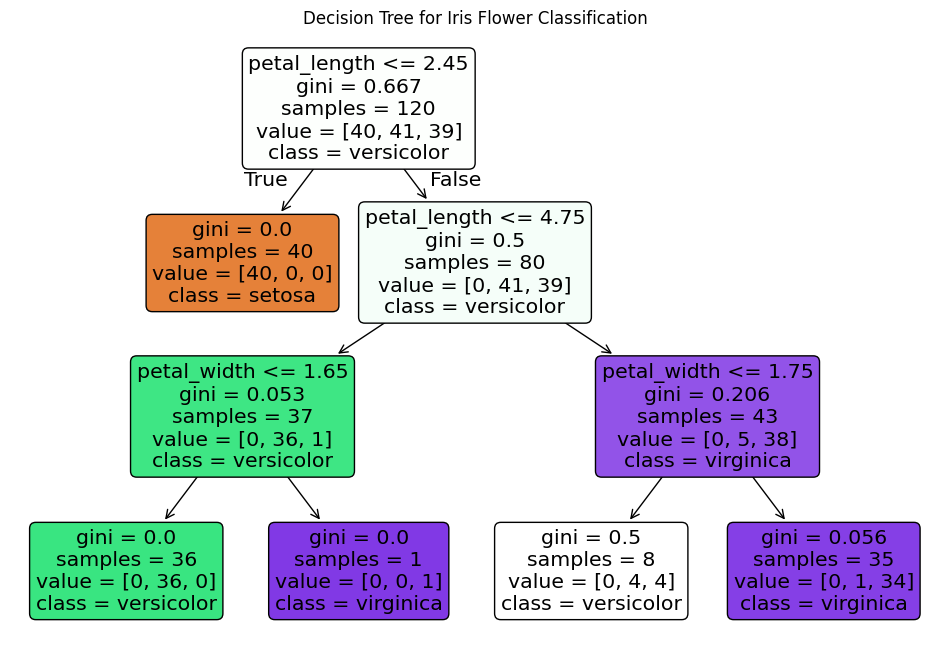

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

X = iris_df.drop('species', axis=1)
y = iris_df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)


y_pred = tree_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("--- Decision Tree Model Evaluation ---")
print("Accuracy :", accuracy)
print("F1-Score:", f1)


plt.figure(figsize=(12, 8))
plot_tree(tree_model, feature_names=X.columns, class_names=tree_model.classes_, filled=True, rounded=True)
plt.title("Decision Tree for Iris Flower Classification")
plt.show()

In [7]:
import pandas as pd


iris_df = pd.read_csv('/content/1) iris.csv')


iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


--- Logistic Regression Model Evaluation ---
Accuracy (Niwradithawaya): 0.8530734632683659
Precision: 0.4594594594594595
Recall: 0.17894736842105263

--- Churn weemata wadiyenma balapana hethu (Top Features) ---
                   Feature  Coefficient  Odds Ratio
15  Customer service calls     0.662390    1.939422
16  International plan_Yes     0.630582    1.878703
2    Number vmail messages     0.413031    1.511392
5         Total day charge     0.340067    1.405042
3        Total day minutes     0.339970    1.404906


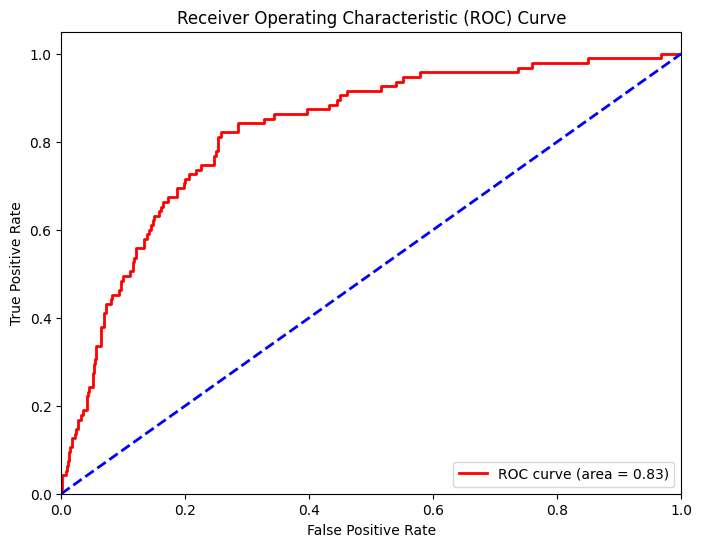

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)


y_pred = log_model.predict(X_test_scaled)
y_pred_prob = log_model.predict_proba(X_test_scaled)[:, 1]


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("--- Logistic Regression Model Evaluation ---")
print("Accuracy (Niwradithawaya):", accuracy)
print("Precision:", precision)
print("Recall:", recall)


feature_names = X_train.columns
coefficients = log_model.coef_[0]
odds_ratios = np.exp(coefficients)

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients, 'Odds Ratio': odds_ratios})
print("\n--- Churn weemata wadiyenma balapana hethu (Top Features) ---")
print(coef_df.sort_values(by='Odds Ratio', ascending=False).head())


fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [10]:

train_df = train_df.drop('State', axis=1)
test_df = test_df.drop('State', axis=1)


train_df['Churn'] = train_df['Churn'].astype(int)
test_df['Churn'] = test_df['Churn'].astype(int)


X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']

X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn']


X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing done successfully!")

Data Preprocessing done successfully!


In [9]:
import pandas as pd


train_df = pd.read_csv('/content/churn-bigml-80.csv')
test_df = pd.read_csv('/content/churn-bigml-20.csv')


print("Train data rows and columns:", train_df.shape)
print("Test data rows and columns:", test_df.shape)


train_df.head()

Train data rows and columns: (2666, 20)
Test data rows and columns: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
